In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

In [2]:
#read csv files
train_df = pd.read_csv('cleaned_train.csv')
test_df = pd.read_csv('cleaned_test.csv')

#**Feature Engineering**

Feature scaling using Robust scaling

In [3]:
#Robust scaling for train data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
train_df[['luxury_sales', 'fresh_sales', 'dry_sales']] = scaler.fit_transform(train_df[['luxury_sales', 'fresh_sales', 'dry_sales']])
train_df

,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,Kelaniya,-0.449398,-0.515247,0.291511,4.0
1,Moratuwa,-0.111417,-0.455032,0.424636,1.0
2,Wattala,0.509227,-0.371672,1.010734,4.0
3,Wattala,0.496846,-0.320459,1.000354,4.0
4,Kelaniya,0.559509,-0.255133,1.027203,4.0
...,...,...,...,...,...
771203,Gampaha,1.934375,0.106032,-0.051681,3.0
771204,Katunayake,3.890617,0.435659,0.474532,3.0
771205,Colombo,3.025112,0.289552,0.175634,3.0
771206,Kandy,4.082381,0.584923,0.412231,3.0


In [4]:
#Robust scaling for test data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
test_df[['luxury_sales', 'fresh_sales', 'dry_sales']] = scaler.fit_transform(test_df[['luxury_sales', 'fresh_sales', 'dry_sales']])
test_df

,outlet_city,luxury_sales,fresh_sales,dry_sales
0,Batticaloa,0.857036,0.041934,1.631142
1,Batticaloa,-0.003678,-0.156127,1.057114
2,Batticaloa,-0.770746,-0.418872,0.268686
3,Batticaloa,-0.074244,-0.206480,1.026671
4,Batticaloa,-0.606366,-0.364430,0.312032
...,...,...,...,...
40738,Wattala,1.949633,0.156016,0.029931
40739,Wattala,1.306003,-0.071869,-0.122090
40740,Wattala,1.880452,0.114705,-0.010279
40741,Wattala,2.302539,0.160306,0.103723


Feature Selection - LabelEncoder

In [5]:
#label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

#all values in 'outlet_city' are converted to string before fitting
train_df['outlet_city'] = train_df['outlet_city'].astype(str)
test_df['outlet_city'] = test_df['outlet_city'].astype(str)

#Fit on the combined unique values from both train and test data
all_cities = pd.concat([train_df['outlet_city'], test_df['outlet_city']]).unique()
label_encoder.fit(all_cities)

#Transform the columns in both dataframes
train_df['outlet_city'] = label_encoder.transform(train_df['outlet_city'])
test_df['outlet_city'] = label_encoder.transform(test_df['outlet_city'])

In [6]:
train_df

,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,12,-0.449398,-0.515247,0.291511,4.0
1,15,-0.111417,-0.455032,0.424636,1.0
2,21,0.509227,-0.371672,1.010734,4.0
3,21,0.496846,-0.320459,1.000354,4.0
4,12,0.559509,-0.255133,1.027203,4.0
...,...,...,...,...,...
771203,5,1.934375,0.106032,-0.051681,3.0
771204,11,3.890617,0.435659,0.474532,3.0
771205,2,3.025112,0.289552,0.175634,3.0
771206,10,4.082381,0.584923,0.412231,3.0


#**KNN** **Model**

In [7]:
#Check the data type of 'cluster_category'
print(train_df['cluster_category'].dtype)

float64


In [8]:
#Separate features to predict customer category and the target variable
X = train_df.drop(columns=['cluster_category'])
y = train_df['cluster_category']

In [9]:
#Train-Test Split
# Impute or remove NaN values from y before splitting
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14, stratify=y)
# Create validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=14, stratify=y_train)

In [10]:
#number of instances and input features in the training and test sets
print('X_train Instances', X_train.shape)
print('X_test Instances', X_test.shape)

X_train Instances (493572, 4)
X_test Instances (154242, 4)


In [11]:
#pearsons correlation
correlation = X_train.corr(method='pearson')
print(correlation)

              outlet_city  luxury_sales  fresh_sales  dry_sales
outlet_city      1.000000     -0.079210    -0.070077  -0.045770
luxury_sales    -0.079210      1.000000     0.311158   0.154900
fresh_sales     -0.070077      0.311158     1.000000  -0.535187
dry_sales       -0.045770      0.154900    -0.535187   1.000000


In [12]:
#find the number of n_neighbors using gridsearch
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 3


In [13]:
#KNN classifier
knn = KNeighborsClassifier(n_neighbors = 3)
#Fit the classifier to the data
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [14]:
#Perform predictions on the test data
y_pred=knn.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results by kNN mode
knn_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
knn_results.head()

,Actual,Predicted
413925,1.0,1.0
193845,2.0,2.0
137184,4.0,4.0
127008,4.0,4.0
187938,2.0,2.0


In [15]:
#cross validation to handle mislassification
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, X_train, y_train, cv=3)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.99974472 0.99972648 0.99974472]
Mean cross-validation score: 0.9997386399552649


In [16]:
#check for misclassification
misclassified = knn_results[knn_results['Actual'] != knn_results['Predicted']]
print(misclassified)

        Actual  Predicted
327986     6.0        5.0
1721       5.0        4.0
173280     1.0        2.0
2465       5.0        4.0
749714     6.0        3.0
555561     5.0        6.0
327126     4.0        5.0
326627     3.0        5.0
555701     5.0        6.0
365836     3.0        1.0
730769     2.0        3.0
748910     4.0        3.0
326792     4.0        5.0
495535     5.0        3.0
555307     2.0        6.0
611        1.0        4.0
3772       6.0        4.0
722926     1.0        3.0
749022     4.0        3.0
555642     5.0        6.0
325881     2.0        4.0
327749     6.0        5.0
722786     1.0        3.0
365453     3.0        1.0
555184     1.0        6.0
731022     2.0        3.0
555259     2.0        6.0
366726     6.0        1.0
366184     6.0        1.0
365925     4.0        1.0
722605     5.0        3.0
692600     6.0        3.0


[[37660     1     2     1     0     1]
 [    0 30872     2     1     0     2]
 [    2     0  9769     0     1     0]
 [    1     0     2 34295     2     0]
 [    0     0     2     2  7894     3]
 [    2     0     2     1     2 33720]]


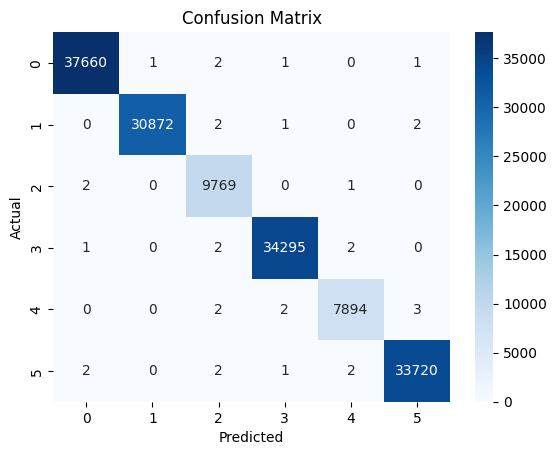

In [17]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = knn.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9997925338105056
Training Accuracy: 0.9997507962364154
Testing Accuracy: 0.9997925338105056
The model is well-fitted.


In [19]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37665
         2.0       1.00      1.00      1.00     30877
         3.0       1.00      1.00      1.00      9772
         4.0       1.00      1.00      1.00     34300
         5.0       1.00      1.00      1.00      7901
         6.0       1.00      1.00      1.00     33727

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



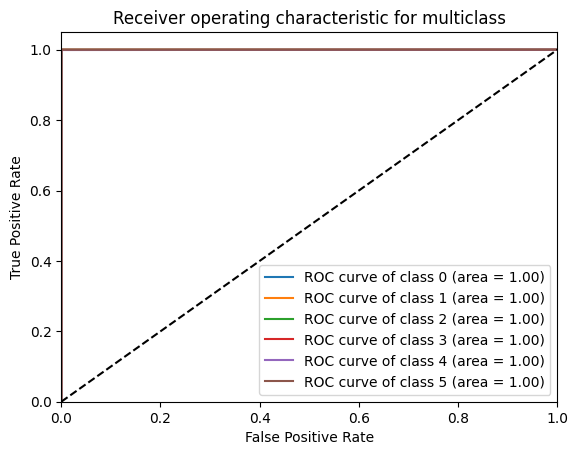

In [20]:
#ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
#Assuming y_test and y_pred are your true and predicted labels

#Binarize the output
lb = LabelBinarizer()
lb.fit(y_test)
y_test_bin = lb.transform(y_test)
y_pred_bin = lb.transform(y_pred)

#Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#Plot all ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic for multiclass")
plt.legend(loc="lower right")
plt.show()

#**Logistic Regression Model**

In [21]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [22]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [23]:
#pearsons coefficient
correlation = X_train.corr(method='pearson')
print(correlation)

              luxury_sales  fresh_sales  dry_sales  outlet_city
luxury_sales      1.000000     0.310962   0.155055    -0.078401
fresh_sales       0.310962     1.000000  -0.536023    -0.069939
dry_sales         0.155055    -0.536023   1.000000    -0.044507
outlet_city      -0.078401    -0.069939  -0.044507     1.000000


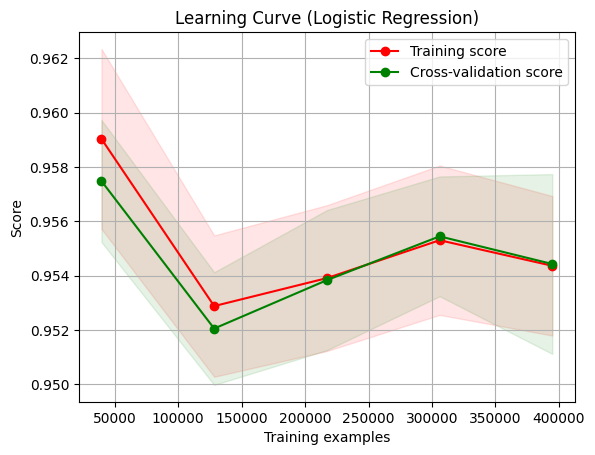

In [24]:
#learning curve using a sample size of 250,000
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

plot_learning_curve(LogisticRegression(), "Learning Curve (Logistic Regression)", X_train, y_train, cv=5, n_jobs=-1)
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
#Perform predictions on the test data
y_pred = logreg.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
knn_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
knn_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


In [27]:
#check for misclassifications
misclassified = knn_results[knn_results['Actual'] != knn_results['Predicted']]
print(misclassified)

        Actual  Predicted
756065     3.0        5.0
366438     1.0        4.0
331259     5.0        3.0
645901     6.0        2.0
737111     3.0        5.0
...        ...        ...
349418     5.0        3.0
755902     3.0        5.0
766081     3.0        5.0
738474     3.0        5.0
762235     3.0        5.0

[7189 rows x 2 columns]


[[37532     0     2   225     3     1]
 [    0 30066     1     2     2   698]
 [    1     0  7167    72  2535    40]
 [  245     1     4 33938     1     0]
 [    1     0  2807    46  5073    22]
 [    0   472     3     3     2 33277]]


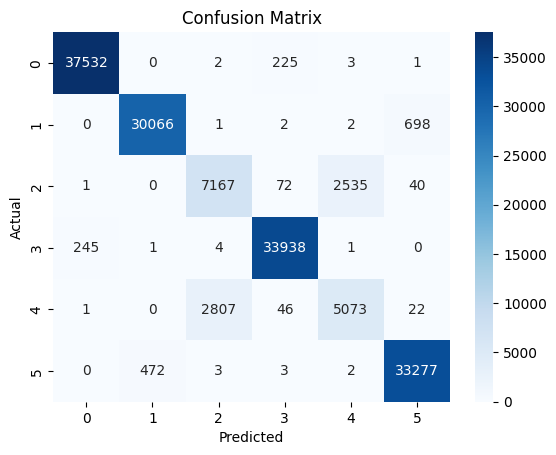

In [28]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = logreg.score(X_train, y_train)
test_accuracy = logreg.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = logreg.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9533914238663918
Training Accuracy: 0.9545152480286564
Testing Accuracy: 0.9533914238663918
The model is well-fitted.


In [30]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99     37763
         2.0       0.98      0.98      0.98     30769
         3.0       0.72      0.73      0.72      9815
         4.0       0.99      0.99      0.99     34189
         5.0       0.67      0.64      0.65      7949
         6.0       0.98      0.99      0.98     33757

    accuracy                           0.95    154242
   macro avg       0.89      0.89      0.89    154242
weighted avg       0.95      0.95      0.95    154242



#**Decision Tree Model**

In [31]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [32]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [33]:
#spearmans correlation
correlation = X_train.corr(method='spearman')
print(correlation)

              luxury_sales  fresh_sales  dry_sales  outlet_city
luxury_sales      1.000000     0.339739   0.294127    -0.077581
fresh_sales       0.339739     1.000000  -0.559672    -0.080532
dry_sales         0.294127    -0.559672   1.000000    -0.018938
outlet_city      -0.077581    -0.080532  -0.018938     1.000000


In [34]:
#decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [35]:
#Perform predictions on the test data
y_pred = dt.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
dt_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
dt_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


In [36]:
#maximum depth of a tree
max_depth = dt.tree_.max_depth
print("Maximum depth of the tree:", max_depth)

Maximum depth of the tree: 23


In [37]:
#optimise the depth
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [3, 4, 5, 6, 7, 8, 9, 10]}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best max_depth:", grid_search.best_params_['max_depth'])

Best max_depth: 10


In [38]:
#check for misclassification
misclassified = dt_results[dt_results['Actual'] != dt_results['Predicted']]
print(misclassified)

        Actual  Predicted
273653     2.0        6.0
722786     1.0        5.0
224848     2.0        6.0
39434      4.0        1.0
764268     3.0        5.0
...        ...        ...
711385     6.0        2.0
342590     5.0        6.0
265208     2.0        6.0
305570     2.0        6.0
733383     3.0        5.0

[272 rows x 2 columns]


[[37706     1     2    49     3     2]
 [    3 30714     3     3     1    45]
 [    4     1  9793     0    14     3]
 [   54     4     1 34124     4     2]
 [    0     2    12     4  7927     4]
 [    2    42     1     4     2 33706]]


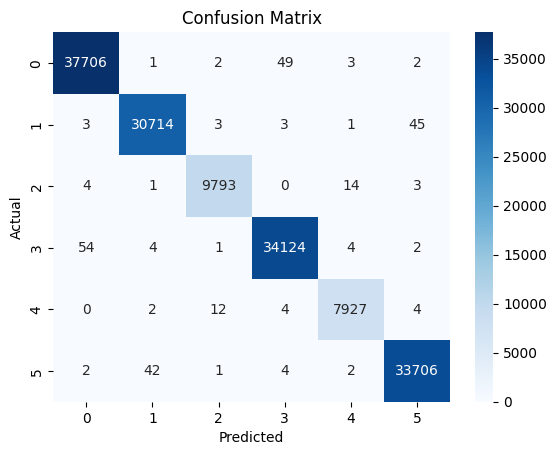

In [39]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

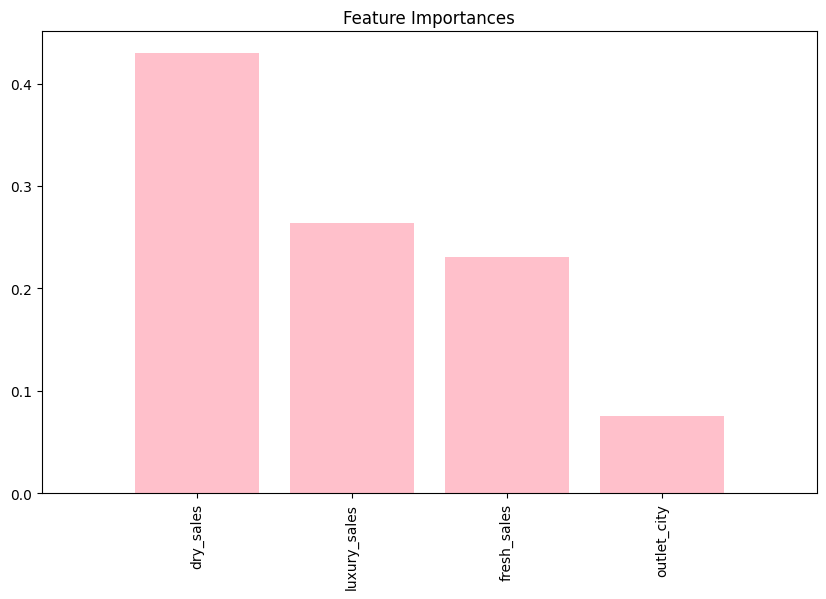

In [40]:
#feature importance using a box plot
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], color="pink", align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

In [41]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = dt.score(X_train, y_train)
test_accuracy = dt.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = dt.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9982365373892973
Training Accuracy: 1.0
Testing Accuracy: 0.9982365373892973
The model is well-fitted.


In [42]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



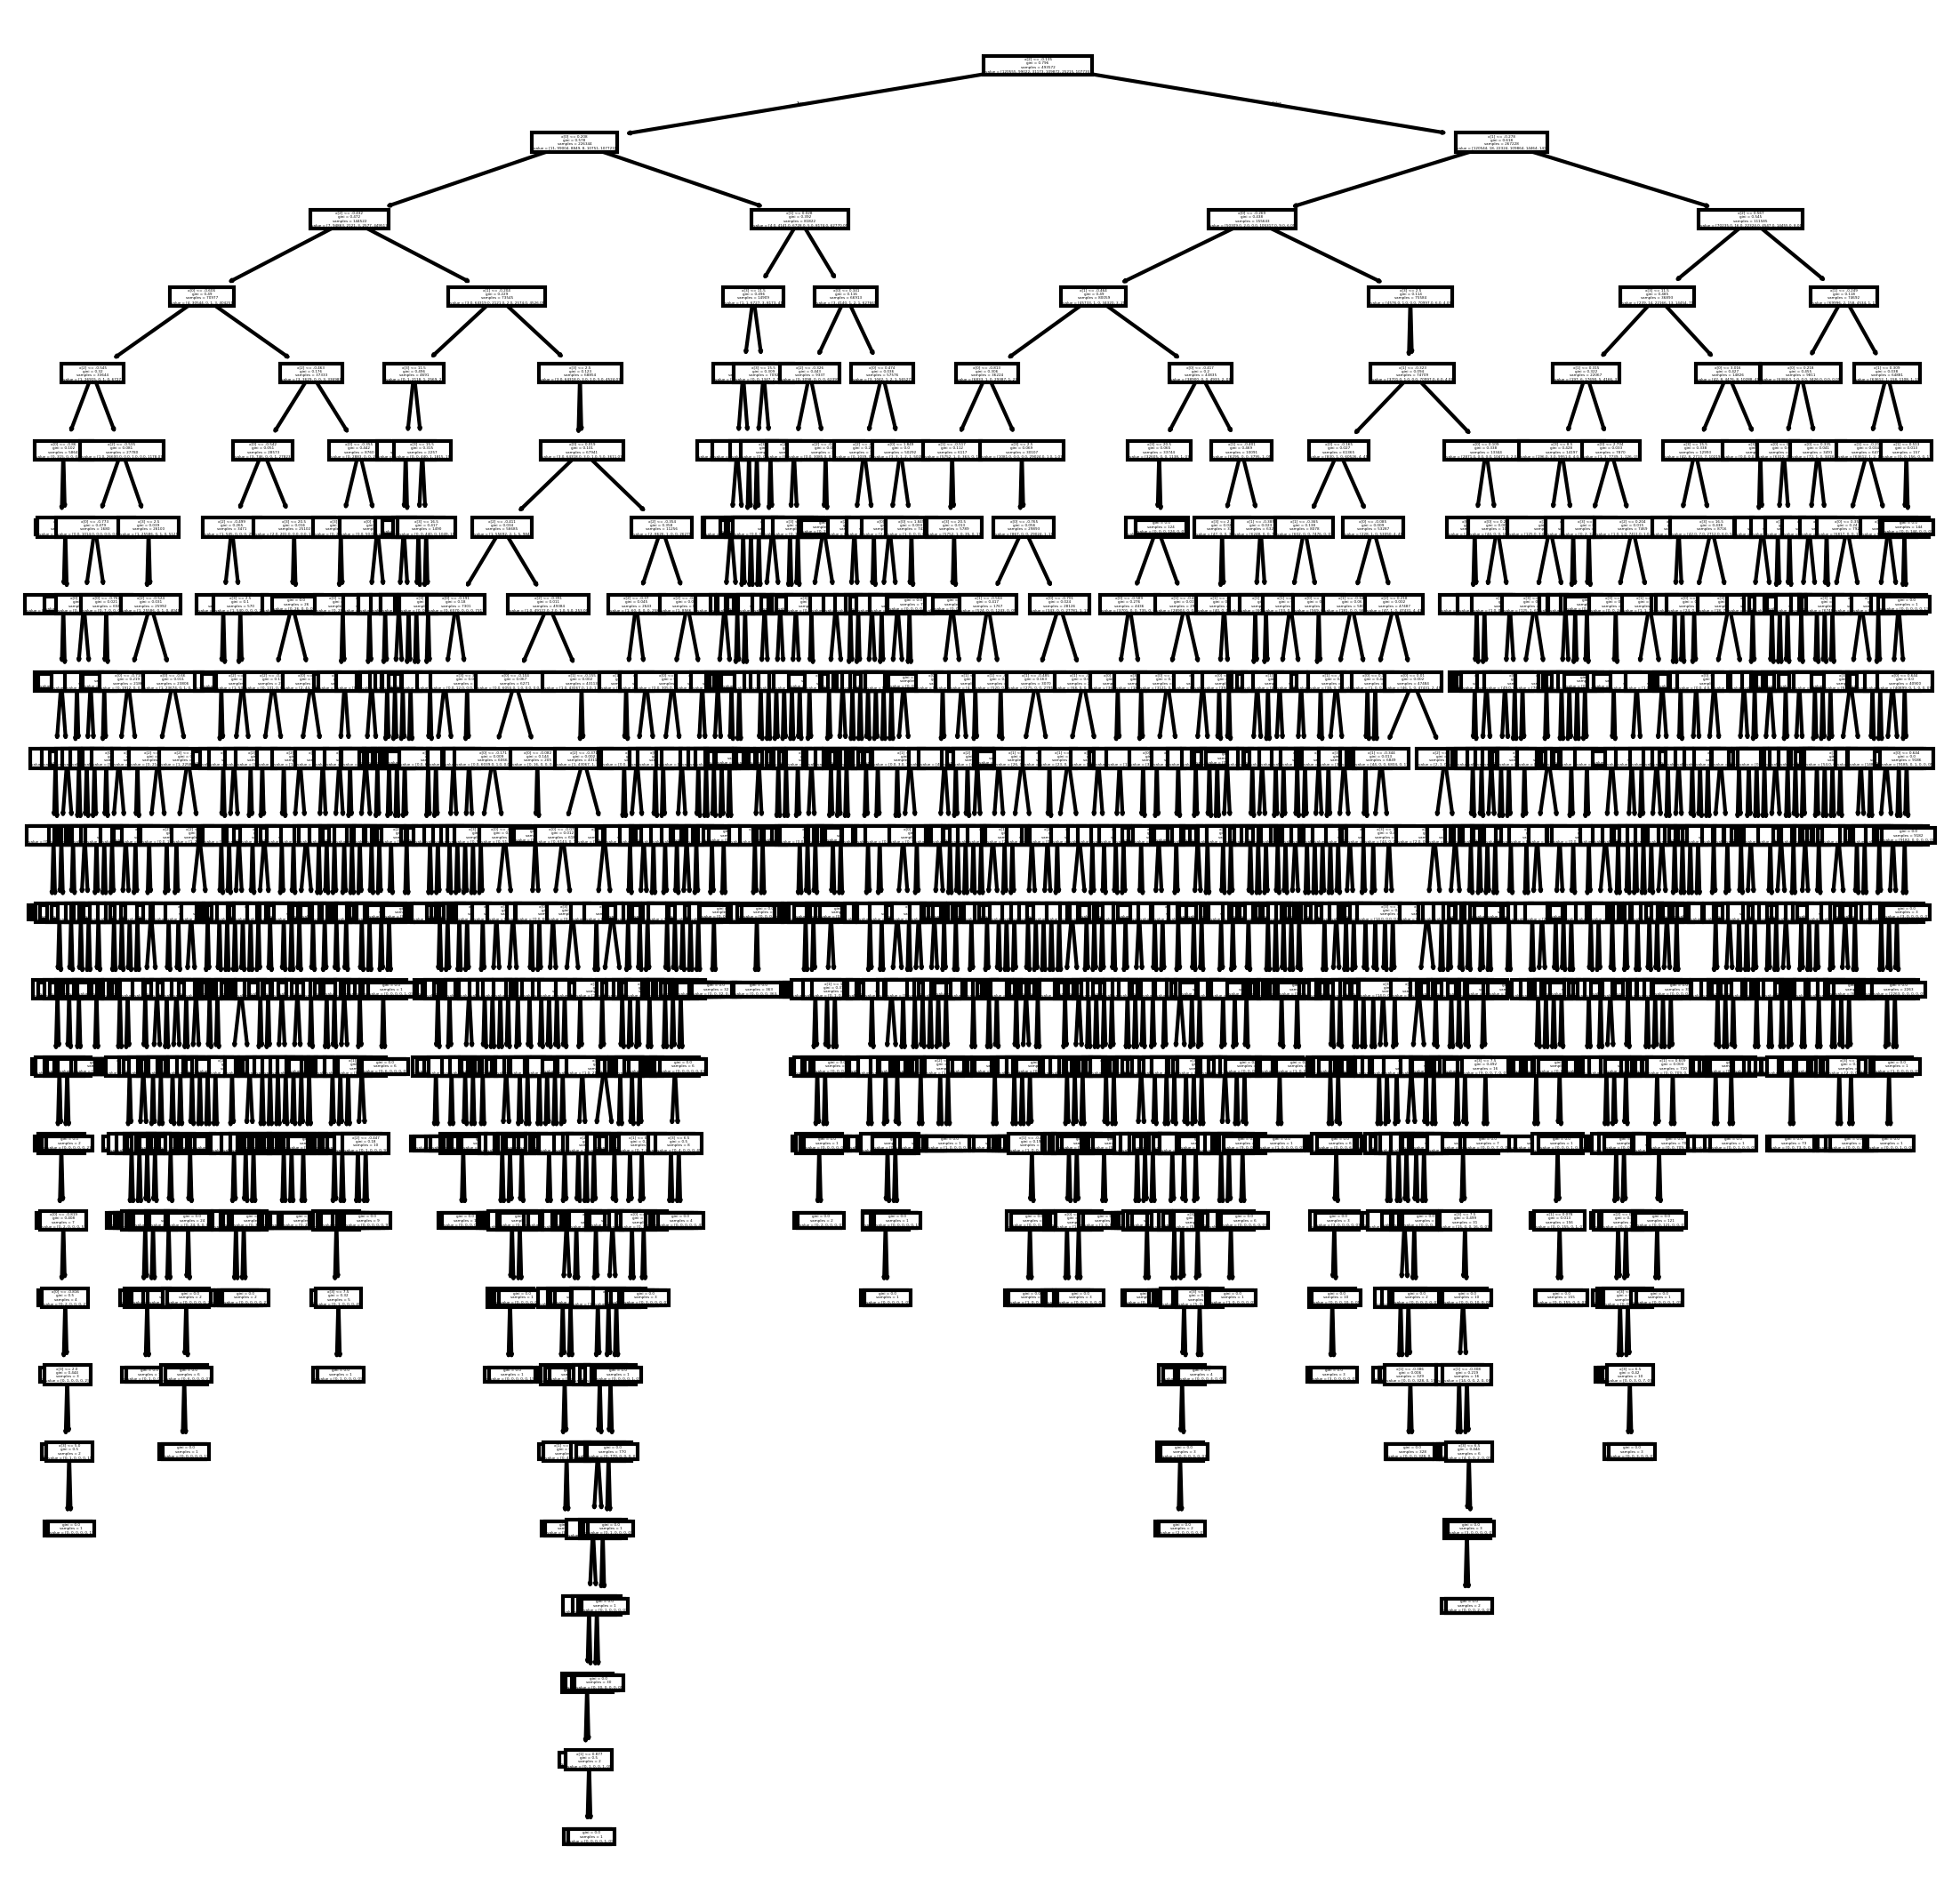

In [43]:
#decision tree diagram
import matplotlib.pyplot as plt
from sklearn import tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9), dpi=300)
tree.plot_tree(dt)
plt.show()

#**Random Forest Classification Model**

In [44]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [45]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [46]:
#spearmans correlation
correlation = X_train.corr(method='spearman')
print(correlation)

              luxury_sales  fresh_sales  dry_sales  outlet_city
luxury_sales      1.000000     0.339739   0.294127    -0.077581
fresh_sales       0.339739     1.000000  -0.559672    -0.080532
dry_sales         0.294127    -0.559672   1.000000    -0.018938
outlet_city      -0.077581    -0.080532  -0.018938     1.000000


In [47]:
#random forest classification
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [48]:
#Perform predictions on the test data
y_pred = rf.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
rf_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
rf_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


In [49]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=3)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.99907004 0.99896064 0.99899103]
Mean cross-validation score: 0.9990072370393782


In [50]:
#check for misclassification
misclassified = rf_results[rf_results['Actual'] != rf_results['Predicted']]
print(misclassified)

        Actual  Predicted
309590     2.0        6.0
722786     1.0        3.0
4224       6.0        4.0
692311     6.0        2.0
514566     1.0        4.0
...        ...        ...
686626     6.0        3.0
411753     1.0        4.0
120862     4.0        1.0
28914      4.0        1.0
288257     2.0        6.0

[122 rows x 2 columns]


[[37732     0     3    26     1     1]
 [    0 30751     1     3     1    13]
 [    3     0  9809     0     1     2]
 [   18     1     1 34167     2     0]
 [    0     0    11     3  7933     2]
 [    0    24     1     3     1 33728]]


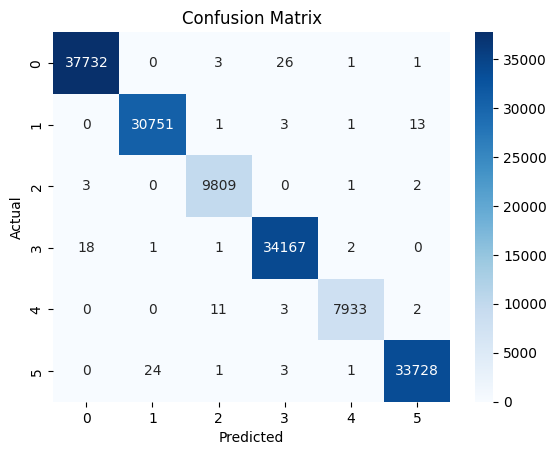

In [51]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

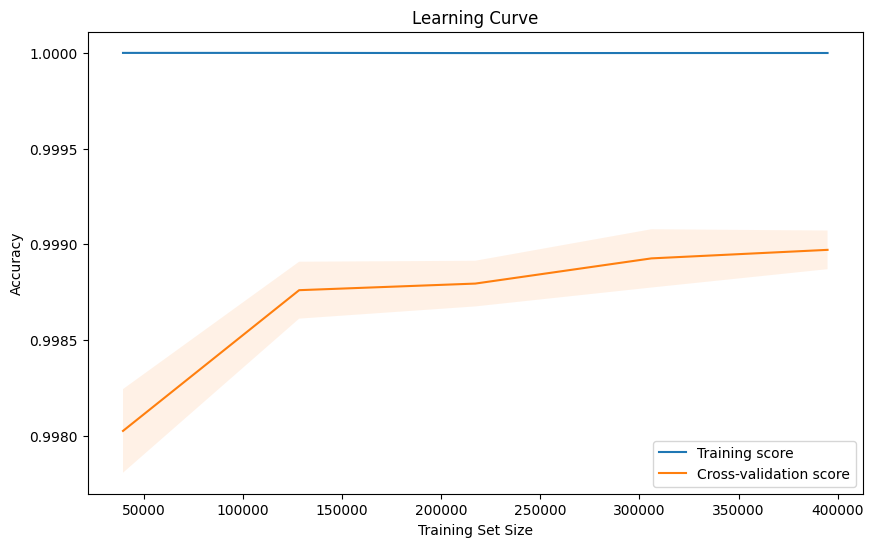

In [52]:
#plotting the learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(rf, X_train, y_train, cv=5, scoring='accuracy')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()

In [53]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = rf.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9992090351525524
Training Accuracy: 1.0
Testing Accuracy: 0.9992090351525524
The model is well-fitted.


In [54]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



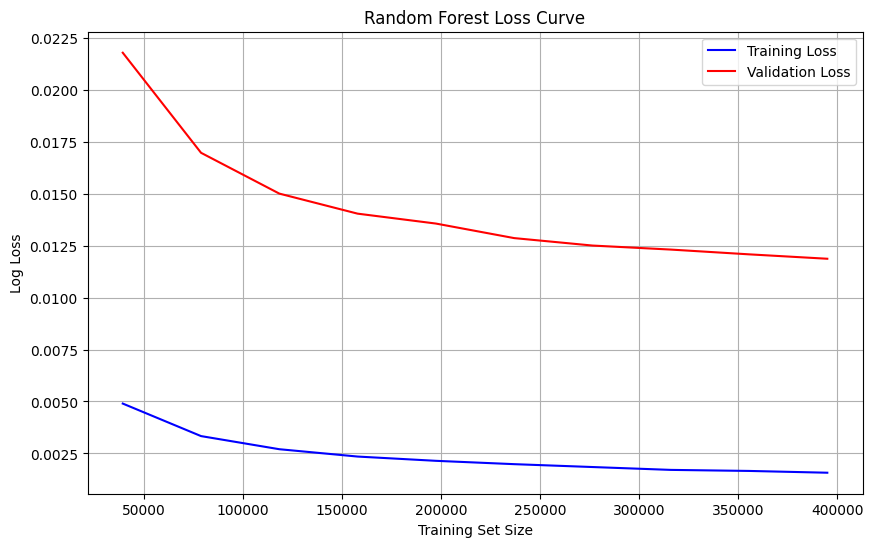

In [55]:
#loss curve
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

#Use learning_curve to get training and validation scores for different training set sizes
train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train, y_train, cv=5, scoring='neg_log_loss',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

#Convert negative log loss scores to positive
train_loss = -np.mean(train_scores, axis=1)
val_loss = -np.mean(val_scores, axis=1)

#Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_loss, label="Training Loss", color="blue")
plt.plot(train_sizes, val_loss, label="Validation Loss", color="red")
plt.xlabel("Training Set Size")
plt.ylabel("Log Loss")
plt.title("Random Forest Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

#**Gradient Boosting Model**

In [56]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [57]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [58]:
#spearmans correlation
correlation = X_train.corr(method='spearman')
print(correlation)

              luxury_sales  fresh_sales  dry_sales  outlet_city
luxury_sales      1.000000     0.339739   0.294127    -0.077581
fresh_sales       0.339739     1.000000  -0.559672    -0.080532
dry_sales         0.294127    -0.559672   1.000000    -0.018938
outlet_city      -0.077581    -0.080532  -0.018938     1.000000


In [59]:
#Gradient boosting model
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [60]:
#Perform predictions on the test data
y_pred = gb.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
gb_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
gb_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


In [61]:
#check for misclassification
misclassified = gb_results[gb_results['Actual'] != gb_results['Predicted']]
print(misclassified)

        Actual  Predicted
722786     1.0        3.0
4224       6.0        4.0
172876     4.0        2.0
370979     1.0        4.0
267347     2.0        5.0
326792     4.0        5.0
1574       5.0        4.0
750364     3.0        1.0
722851     1.0        3.0
27612      4.0        1.0
328069     6.0        5.0
535640     1.0        4.0
95712      4.0        1.0
326915     4.0        5.0
453695     1.0        4.0
1133       2.0        4.0
730769     2.0        3.0
4332       4.0        1.0
3271       6.0        4.0
78178      4.0        1.0
411709     1.0        4.0
385043     1.0        4.0
555953     3.0        6.0
20697      4.0        1.0
584243     6.0        2.0
553289     1.0        3.0
1721       5.0        4.0
722543     4.0        3.0
324974     2.0        6.0
351024     5.0        1.0
325905     1.0        5.0
369106     1.0        4.0
764638     3.0        1.0
3955       6.0        4.0
547180     1.0        4.0
548124     1.0        4.0
572578     6.0        2.0
512804     1

[[37747     0     3    11     1     1]
 [    0 30761     1     2     3     2]
 [    5     0  9808     0     1     1]
 [    7     1     1 34177     3     0]
 [    1     0     0     3  7943     2]
 [    0     4     0     3     1 33749]]


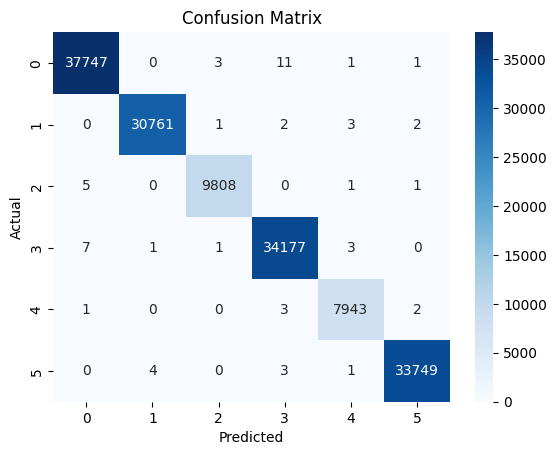

In [62]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [63]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = gb.score(X_train, y_train)
test_accuracy = gb.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = gb.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.999630450849963
Training Accuracy: 0.9997082492523887
Testing Accuracy: 0.999630450849963
The model is well-fitted.


In [64]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



        Feature  Importance
2     dry_sales    0.359213
1   fresh_sales    0.309893
0  luxury_sales    0.269662
3   outlet_city    0.061231


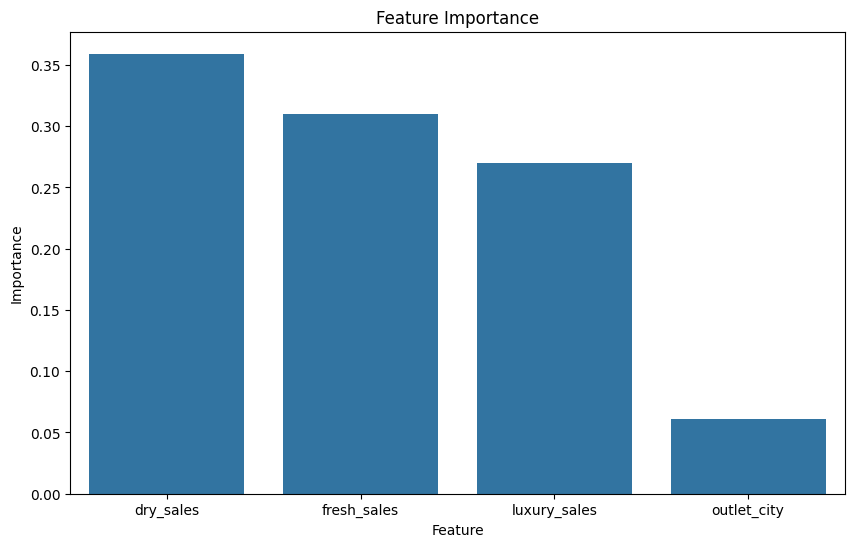

In [65]:
#feature importance as a box plot
feature_importance = gb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()

In [66]:
#Predict clusters
test_predictions = gb.predict(test_df[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']])

#Save predictions as a csv file
#"Customer_ID" was previously dropped. Therefore now we are creating a range of Customer IDs for the prediction DataFrame.
prediction = pd.DataFrame({
    "Customer_ID": range(1, len(test_predictions) + 1),
    "Predicted_Cluster": test_predictions
})
prediction.to_csv("predicted_clusters.csv", index=False)

In [67]:
#save the datasets as new csv files
train_df.to_csv('final_train.csv', index=False)
test_df.to_csv('final_test.csv', index=False)

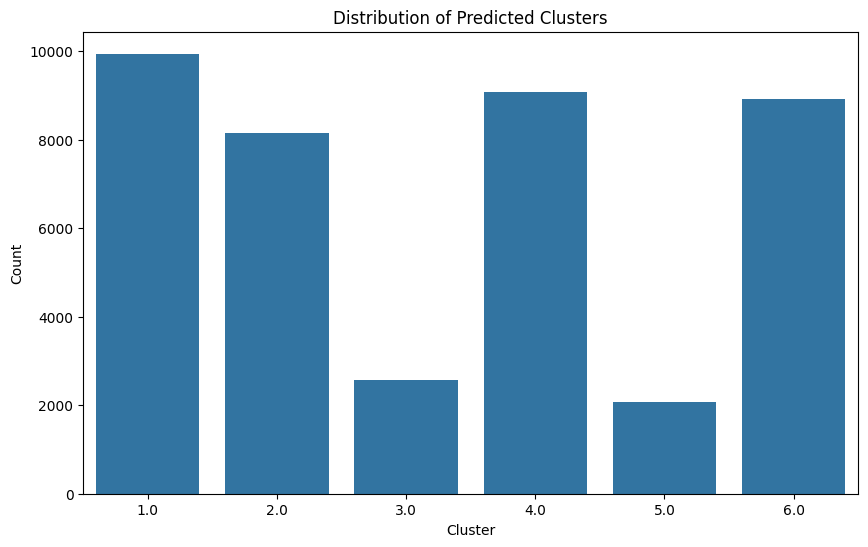

In [68]:
#distribution of predicted customers as a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='Predicted_Cluster', data=prediction)
plt.title('Distribution of Predicted Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()